In [142]:
#1 librerias
%matplotlib inline
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
#plt.style.use('seaborn')
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.metrics import (accuracy_score,f1_score, confusion_matrix, ConfusionMatrixDisplay,r2_score, mean_squared_error)
from sklearn.neighbors import KNeighborsRegressor as KNN
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
)

In [82]:
#2 buscar datos 
# import pandas as pd
# df =pd.read_excel('indicador.xlsx')

california = datasets.fetch_california_housing()
#explorar datos
print(california.feature_names)
print(california.target_names)
print(california.data.shape)


['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
['MedHouseVal']
(20640, 8)


In [84]:
#3 dividir conjuntos. stratify=california.target no se usa para continuo.
X_train, X_test, y_train, y_test = train_test_split(california.data,california.target,
                                                    random_state=42,
                                                    shuffle=True,
                                                    test_size=0.2,
                                                   )

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


Una vez que se entrega el transformer no es hace necesario usar el fit en X_test hola mundo

In [87]:
#4 escalar datos 
sescaler= StandardScaler()
X_train_escalada=sescaler.fit_transform(X_train)
X_test_escalada=sescaler.transform(X_test)
print(X_train_escalada.shape)
print(y_train.reshape(-1,1).shape)
print(type(california.feature_names))

(16512, 8)
(16512, 1)
<class 'list'>


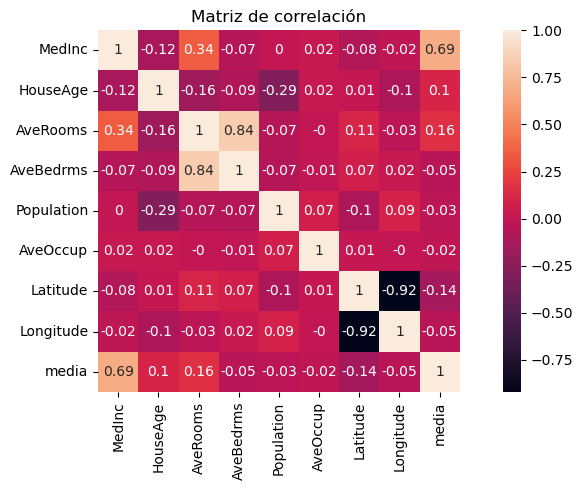

In [91]:
#5 graficar matriz de correlacion con pandas 
californiacon= np.concatenate((X_train_escalada,y_train.reshape(-1,1)),axis=1)
californiapd=pd.DataFrame(californiacon,columns=[*california.feature_names, "media"])
fig,ax=plt.subplots(1,1,figsize=(9,5))
sns.heatmap(californiapd.corr().round(2),annot=True,square=True,ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout() #ajusta los márgenes
plt.show()


In [71]:
#6 reducir las cracterísticas
X_train_escalada_red=X_train_escalada[ : ,[0,1,2]]
X_test_escalada_red=X_test_escalada[ : ,[0,1,2]]
print(X_train_escalada_red.shape)

(16512, 3)


modelo1 = KNN(n_neighbors=5,
              weights="distance" por defecto none), distance se usa para hacer un DW KNN
metric=["manhattan","chebyshev","cosine","minkowski"] "minkowski" va con ,p= 3 o mas 2 es euclidiano y 1 manhattan

In [93]:
# 7 instanciar modelo
modelo = KNN(n_neighbors=50)
modelo1 = KNN(n_neighbors=50,weights=None,metric="minkowski",p=3)
# correr modelo se puede hacer junto classifier = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
clasificarKNN= modelo.fit(X_train_escalada_red,y_train)
clasificarKNN1= modelo1.fit(X_train_escalada_red,y_train)

In [115]:
# 8 score
print("Con train: {:.3f}".format(clasificarKNN.score(X_train_escalada_red,y_train)))
print('Con test: {:.3f}'.format( clasificarKNN.score(X_test_escalada_red,y_test)))
print("Con train1: {:.3f}".format(clasificarKNN1.score(X_train_escalada_red,y_train)))
print('Con test1: {:.3f}'.format( clasificarKNN1.score(X_test_escalada_red,y_test)))
# 8 pcredits

y_test_predictions = clasificarKNN.predict(X_test_escalada_red)




Con train: 0.616
Con test: 0.581
Con train1: 0.616
Con test1: 0.580


In [119]:
# 7 r2 y mse

r2 = r2_score(y_test, y_test_predictions)
mse = mean_squared_error(y_test, y_test_predictions)

print(f"R2 Score (Ajuste): {r2:.4f}")
print(f"MSE (Error promedio): {mse:.4f}")
#####################################abs
print("###################################################")


R2 Score (Ajuste): 0.5806
MSE (Error promedio): 0.5496
###################################################


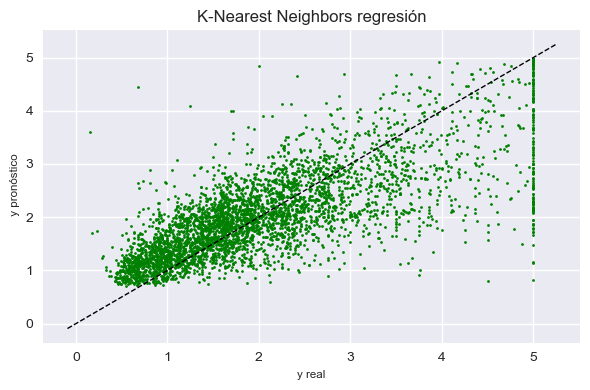

In [208]:
plt.style.use('seaborn-v0_8')

fig,ax=plt.subplots(1,1,figsize=(6, 4))#, dpi = 400)
#plt.subplots_adjust(wspace=0.3, hspace=0.5) ajusta los márgenes manual es mejor plt.tight_layout()
ax.plot(y_test, y_test_predictions, 'g.', markersize=4)
lim_left, lim_right = plt.xlim()
ax.plot([lim_left, lim_right], [lim_left, lim_right], '--k',linewidth=1)
ax.set_xlabel("y real", fontsize='small')
ax.set_ylabel(" y pronóstico", fontsize='small')
ax.set_title("K-Nearest Neighbors regresión")
plt.tight_layout()
plt.show()

In [1]:
%%html
<style>
    .colorfondo {background-color: #D3D3D3; }
     ul {list-style-type: square; /* circle, disc, square */
         padding-left: 20px; }
     li {margin-bottom: 5px; }
</style>

<div class="colorfondo">
<h2>
<b>KNN-KNeighborsRegressor<br> </b>
</h2>

<b>Es un algoritmo simple, intuitivo y flexible, pero puede ser costoso en cómputo y sensible a la elección de parámetros y al ruido en los datos.</b>

<h2 style="color: blue;">
<b>Procedimiento</b><br>
</h2>

 <ol>
     <b><li><b>Librerías.</b></li>
        <li><b>Buscar datos. </b></li>
        <li><b>Analizar datos.</b> </li>
        <li><b>Esacalar datos.</b> </li>
        <li><b>Dividir conjuntos en entrenamiento y prueba o entrenamiento, validación y prueba.</b> </li>
        <li><b>Instanciar el modelo.</b> </li>
        <li><b>Entrenar el modelo. </b> </li>
        <li><b>Evaluar el modelo con score, r2 y mse.</b> </li>
        <li><b>Graficar y_test vs y_predic.</b> </li></b>
      
</ol>


<p>
<b>Ventajas de KNN</b> <br><br>
<ul>      
<li><b>Simplicidad y facilidad de interpretabilidad:</b>  El algoritmo es fácil de entender e implementar. Su lógica se basa en la similitud directa, haciendo que las predicciones sean intuitivas.<br> </li>
<li><b>No requiere entrenamiento (Lazy Learner):</b> KNN no aprende una función específica durante el entrenamiento; simplemente memoriza el conjunto de datos de entrenamiento. Esto significa que el tiempo de entrenamiento es casi nulo.<br> </li>
<li><b>Adaptabilidad:</b> Debido a su naturaleza, se readapta instantáneamente cuando se añaden nuevos datos, lo que lo hace útil en entornos de datos cambiantes.<br> </li>
<li><b>No paramétrico:</b> No hace suposiciones sobre la distribución subyacente de los datos (por ejemplo, no asume linealidad), lo cual es ideal para conjuntos de datos complejos.<br> </li>

</ul>
<b>Desventajas de KNN</b><br><br>
<ul> 
<li><b>Alto costo computacional en inferencia:</b> Como el algoritmo debe calcular la distancia entre la nueva instancia y todos los puntos de entrenamiento para cada predicción, puede ser muy lento y consumir muchos recursos con conjuntos de datos grandes.<br> </li>
<li><b>Sensible a la escala de los datos:</b> Requiere normalizar o estandarizar las características antes de su uso. Si una variable tiene una magnitud mayor, dominará el cálculo de distancia. <br></li>
<li><b>Alto consumo de memoria:</b> Necesita almacenar todo el conjunto de entrenamiento para realizar predicciones. <br></li>
<li><b>Sensible al ruido y valores atípicos:</b> Al promediar los vecinos, los valores atípicos (outliers) pueden distorsionar significativamente la predicción, especialmente si 
 es pequeño. <br></li>
<li><b>La maldición de la dimensionalidad: </b> Su rendimiento disminuye drásticamente a medida que aumenta el número de características (dimensiones), ya que la noción de distancia se vuelve menos significativa. <br></li>
<li><b>Necesidad de sintonizar 'k':</b>  Elegir un valor inapropiado para el número de vecinos (k) puede llevar a un ajuste insuficiente (underfitting) o excesivo (overfitting). <br><br></li>
</ul>

<b>En resumen, KNN es ideal para problemas donde la interpretabilidad y la simplicidad son importantes, pero requiere cuidado en la selección de parámetros y puede ser ineficiente para grandes volúmenes de datos o conjuntos de alta dimensionalidad.</b></p>
</div>